# Category-Level Analysis of Trending YouTube Videos

This notebook mirrors `country_analysis.ipynb`, but the primary slice is **YouTube category** (mapped from `category_id`). Where country-level analysis looked at *category mix within each country*, here we look at *country mix within each category*, and we adapt overlap metrics (a video belongs to a single category, so video–video Jaccard across categories is not meaningful; we use **channel overlap** instead).


### Imports and Data Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [3]:
data = "../data/"

df_us = pd.read_csv(data + "USvideos.csv")
df_ca = pd.read_csv(data + "CAvideos.csv")
df_de = pd.read_csv(data + "DEvideos.csv")
df_fr = pd.read_csv(data + "FRvideos.csv")
df_gb = pd.read_csv(data + "GBvideos.csv")
df_in = pd.read_csv(data + "INvideos.csv")
df_jp = pd.read_csv(
    data + "JPvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_kr = pd.read_csv(
    data + "KRvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_mx = pd.read_csv(
    data + "MXvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_ru = pd.read_csv(
    data + "RUvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)


### Pre-processing


In [4]:
df_us["country"] = "US"
df_ca["country"] = "CA"
df_de["country"] = "DE"
df_fr["country"] = "FR"
df_gb["country"] = "GB"
df_in["country"] = "IN"
df_jp["country"] = "JP"
df_kr["country"] = "KR"
df_mx["country"] = "MX"
df_ru["country"] = "RU"

df = pd.concat(
    [df_us, df_ca, df_de, df_fr, df_gb, df_in, df_jp, df_kr, df_mx, df_ru],
    ignore_index=True
)

category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music",
    15: "Pets & Animals", 17: "Sports", 18: "Short Movies",
    19: "Travel & Events", 20: "Gaming", 21: "Videoblogging",
    22: "People & Blogs", 23: "Comedy", 24: "Entertainment",
    25: "News & Politics", 26: "Howto & Style", 27: "Education",
    28: "Science & Technology", 29: "Nonprofits & Activism",
    30: "Movies", 43: "Shows", 44: "Trailers"
}
df["category"] = df["category_id"].map(category_map).fillna("Other")

df.shape


(375942, 18)

In [5]:
df = df.drop_duplicates()

df["description"] = df["description"].fillna("No description")
df["has_description"] = df["description"] != "No description"

df["trending_date"] = df["trending_date"].astype(str).str.strip()
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m",
    errors="coerce"
)

df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df["publish_time"] = df["publish_time"].dt.tz_localize(None)

df["publish_hour"] = df["publish_time"].dt.hour
df["publish_day"] = df["publish_time"].dt.day_name()
df["days_to_trending"] = (df["trending_date"] - df["publish_time"]).dt.days

# Order categories by volume for consistent plot ordering
category_order = (
    df.groupby("category")["video_id"].nunique().sort_values(ascending=False).index.tolist()
)

df.head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,category,has_description,publish_hour,publish_day,days_to_trending
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US,People & Blogs,True,17,Monday,0
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US,Entertainment,True,7,Monday,0
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,US,Comedy,True,19,Sunday,1
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US,Entertainment,True,11,Monday,0
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US,Entertainment,True,18,Sunday,1


## 1. Trending Volume per Category

How many trending entries does each category have, and how many unique videos does that represent?


In [6]:
volume = df.groupby("category").agg(
    total_entries=("video_id", "size"),
    unique_videos=("video_id", "nunique")
)
volume["avg_days_on_trending"] = volume["total_entries"] / volume["unique_videos"]
volume = volume.reindex(category_order)
volume


,total_entries,unique_videos,avg_days_on_trending
category,,,
Entertainment,104567,52961,1.974415
People & Blogs,52297,33280,1.571424
News & Politics,35746,22198,1.610325
Sports,23035,13550,1.700000
Comedy,26077,10742,2.427574
Music,41454,10535,3.934884
Howto & Style,18554,9747,1.903560
Film & Animation,20193,9236,2.186336
Gaming,11063,5592,1.978362


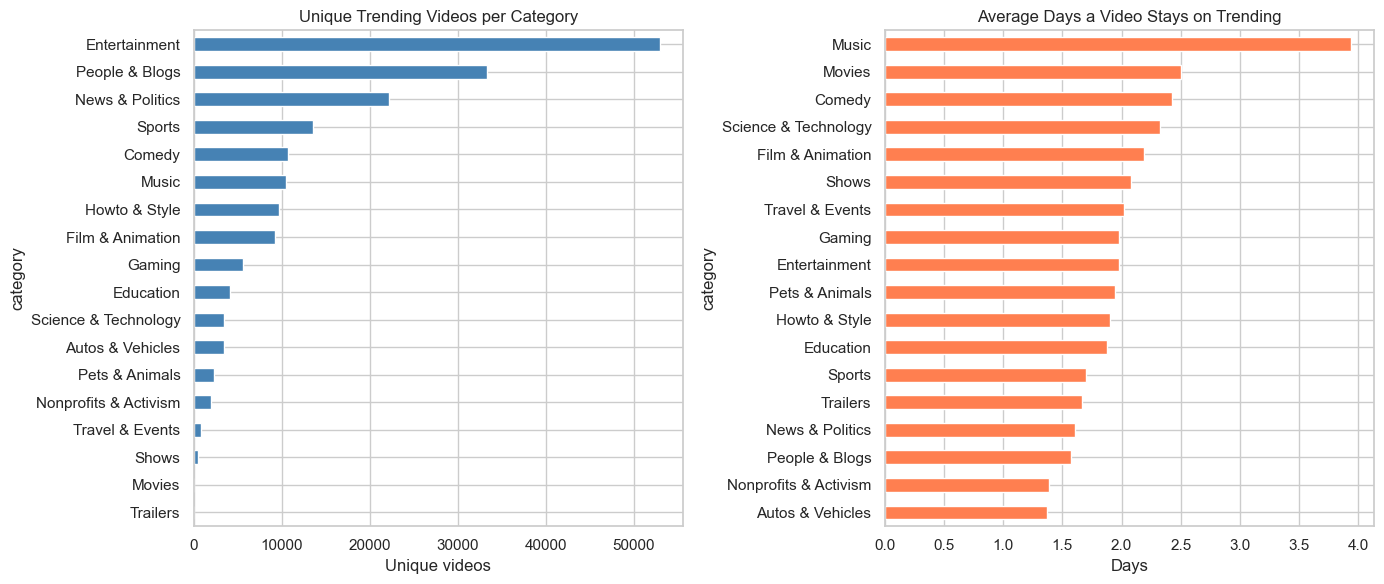

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

volume["unique_videos"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Unique Trending Videos per Category")
axes[0].set_xlabel("Unique videos")

volume["avg_days_on_trending"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Average Days a Video Stays on Trending")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.savefig("exploration_images/category_volume.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Engagement Distributions by Category

Comparing distributions of views, likes, and comments across categories (log scale).


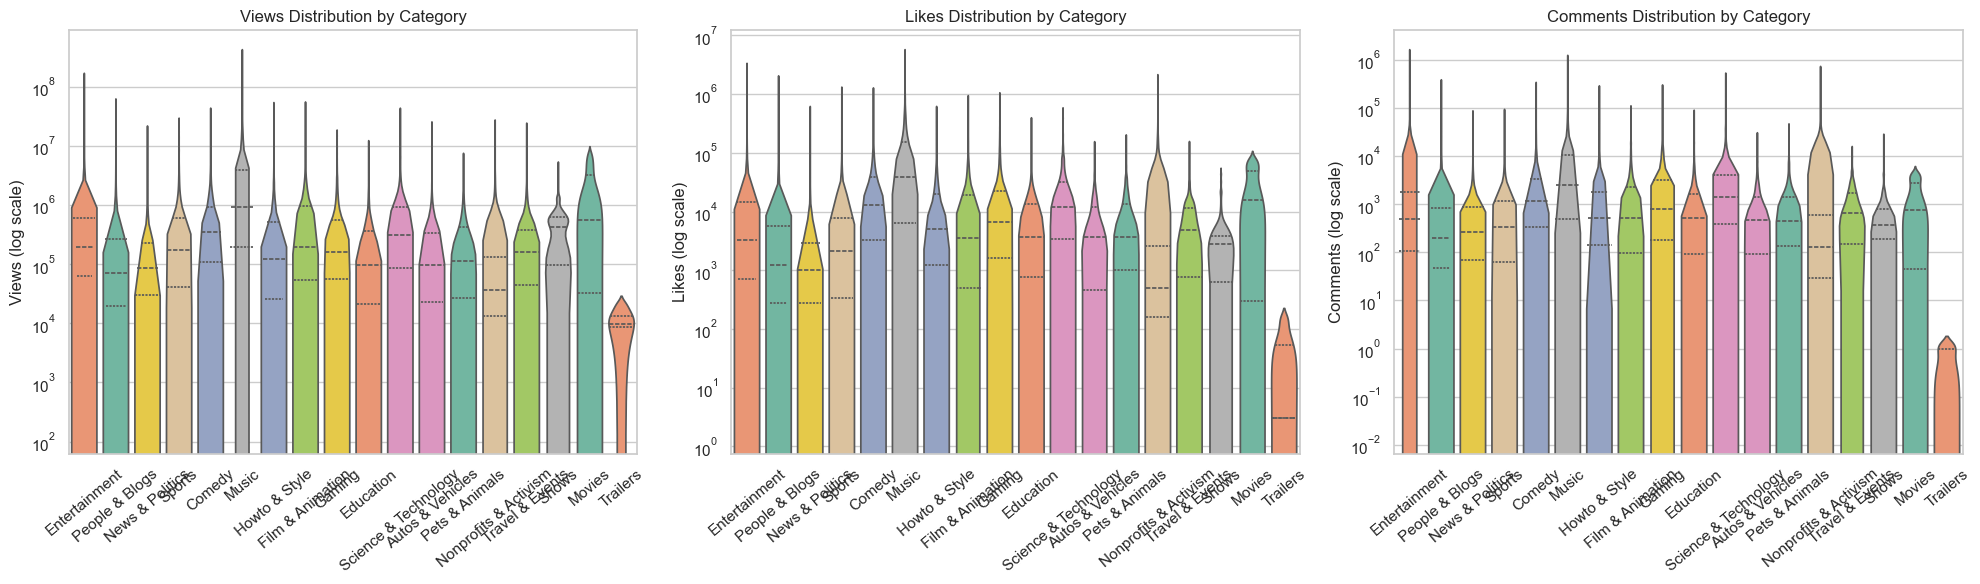

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, title in zip(
    axes,
    ["views", "likes", "comment_count"],
    ["Views", "Likes", "Comments"]
):
    sns.violinplot(
        data=df,
        x="category",
        y=col,
        order=category_order,
        hue="category",
        dodge=False,
        inner="quartile",
        ax=ax,
        palette="Set2",
        legend=False,
        density_norm="width",
    )
    ax.set_yscale("log")
    ax.set_title(f"{title} Distribution by Category")
    ax.set_xlabel("")
    ax.set_ylabel(f"{title} (log scale)")
    ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("exploration_images/category_engagement_dist.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
median_stats = df.groupby("category")[["views", "likes", "dislikes", "comment_count"]].median()
median_stats = median_stats.reindex(category_order)
median_stats.columns = ["Median Views", "Median Likes", "Median Dislikes", "Median Comments"]
median_stats


,Median Views,Median Likes,Median Dislikes,Median Comments
category,,,,
Entertainment,198682.0,3306.0,195.0,502.0
People & Blogs,71868.0,1215.0,72.0,202.0
News & Politics,85347.5,1002.0,100.0,269.0
Sports,173177.0,2134.0,118.0,343.0
Comedy,345619.0,13096.0,399.0,1177.0
Music,935850.0,38962.5,916.0,2462.0
Howto & Style,122998.0,5019.0,153.0,525.0
Film & Animation,197958.0,3557.0,165.0,516.0
Gaming,162806.0,6559.0,182.0,778.0


## 3. Engagement Rates by Category

Normalized by views: like rate, dislike rate, comment rate, and like/dislike ratio.


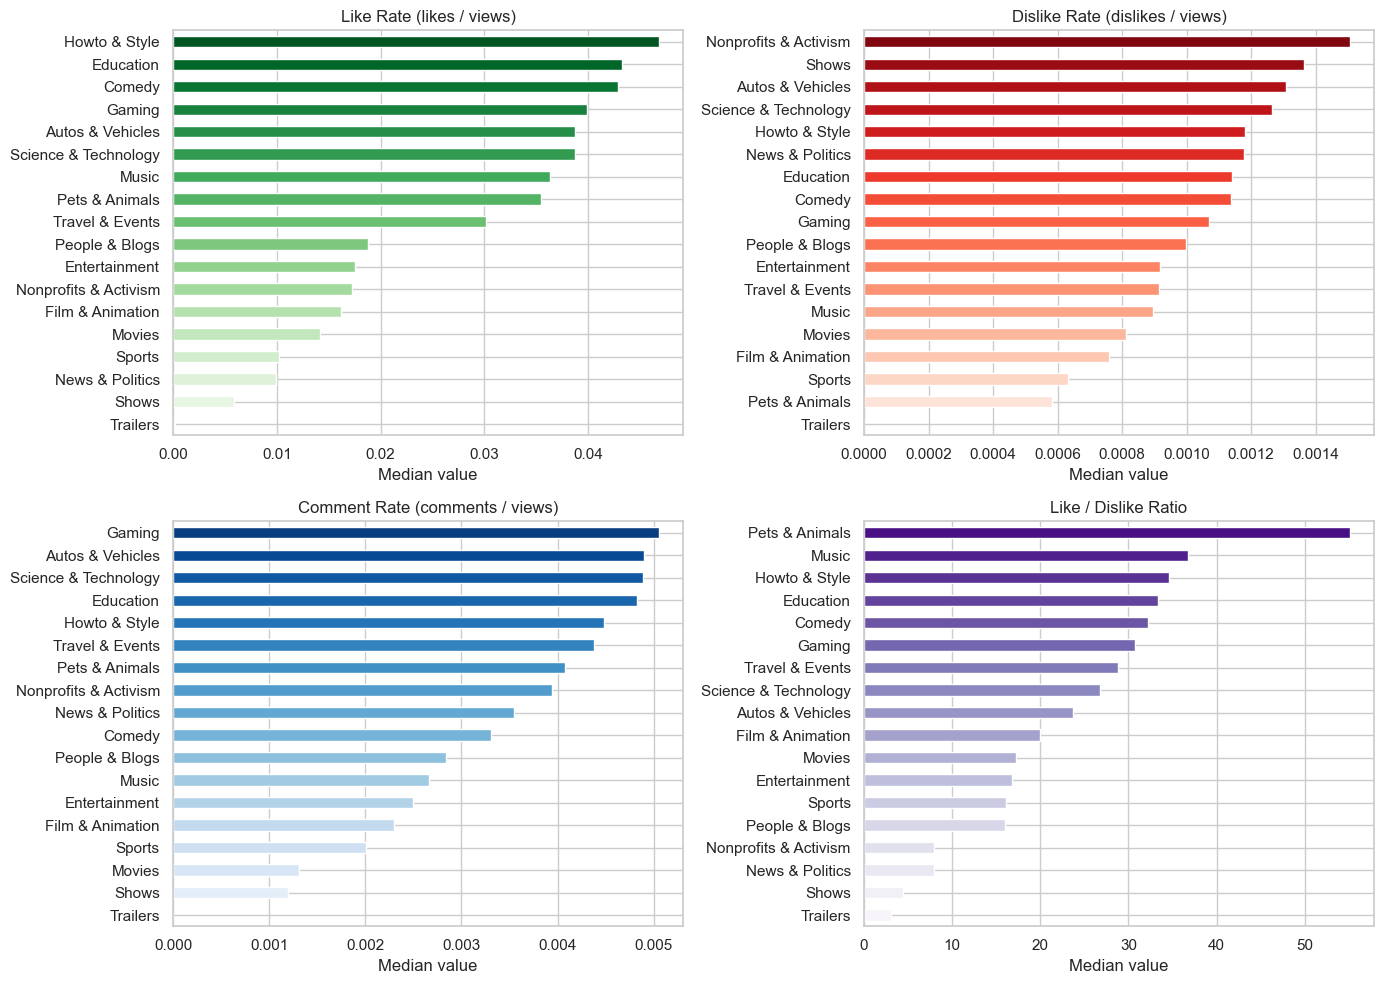

In [10]:
df["like_rate"] = df["likes"] / df["views"]
df["dislike_rate"] = df["dislikes"] / df["views"]
df["comment_rate"] = df["comment_count"] / df["views"]
df["like_dislike_ratio"] = df["likes"] / (df["dislikes"] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("like_rate", "Like Rate (likes / views)", "Greens"),
    ("dislike_rate", "Dislike Rate (dislikes / views)", "Reds"),
    ("comment_rate", "Comment Rate (comments / views)", "Blues"),
    ("like_dislike_ratio", "Like / Dislike Ratio", "Purples"),
]

for ax, (col, title, cmap) in zip(axes.flat, metrics):
    medians = df.groupby("category")[col].median().reindex(category_order).sort_values(ascending=True)
    medians.plot.barh(ax=ax, color=sns.color_palette(cmap, len(medians)))
    ax.set_title(title)
    ax.set_xlabel("Median value")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("exploration_images/category_engagement_rates.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Country Mix by Category

For each category, what share of trending entries comes from each country? (Inverse of the country notebook’s category-by-country heatmap.)


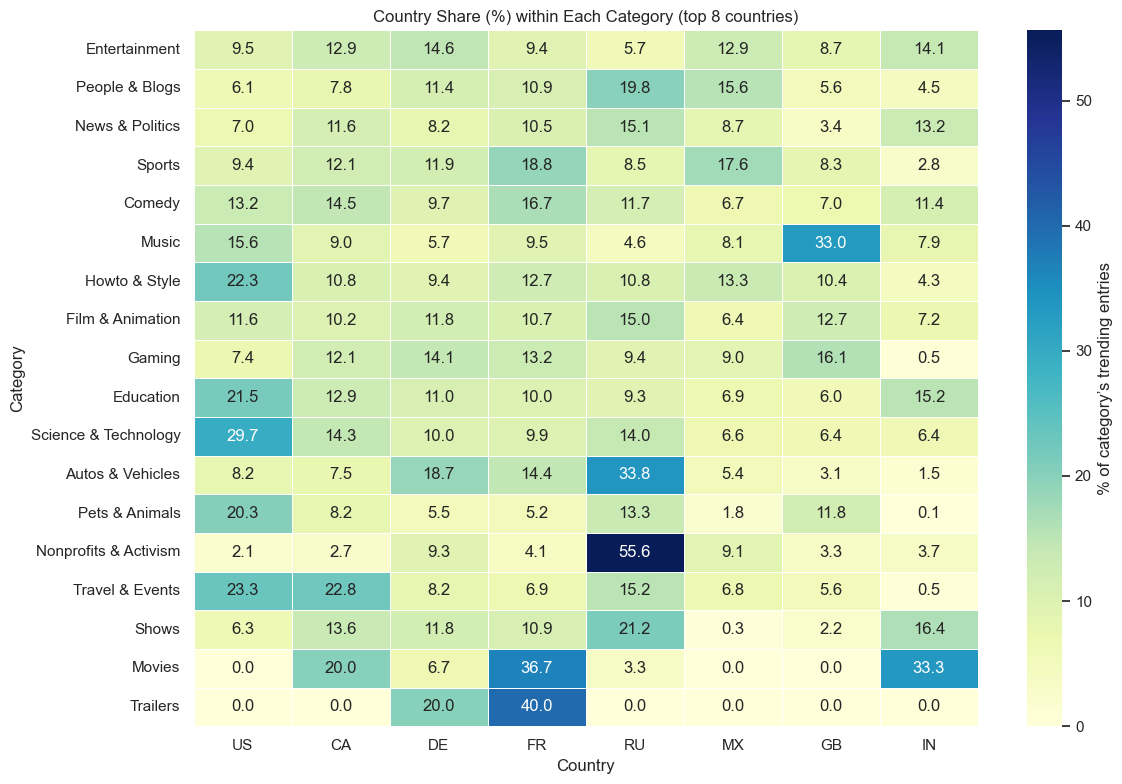

In [11]:
country_cat = (
    df.groupby(["category", "country"])
    .size()
    .unstack(fill_value=0)
)
country_cat_pct = country_cat.div(country_cat.sum(axis=1), axis=0) * 100

top_countries = country_cat.sum().nlargest(8).index
heat = country_cat_pct[top_countries].reindex(category_order)

plt.figure(figsize=(12, 8))
sns.heatmap(
    heat, annot=True, fmt=".1f", cmap="YlGnBu",
    linewidths=0.5, cbar_kws={"label": "% of category’s trending entries"}
)
plt.title("Country Share (%) within Each Category (top 8 countries)")
plt.xlabel("Country")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("exploration_images/category_country_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Time to Trending by Category

How quickly do videos reach trending after publish, by content category?


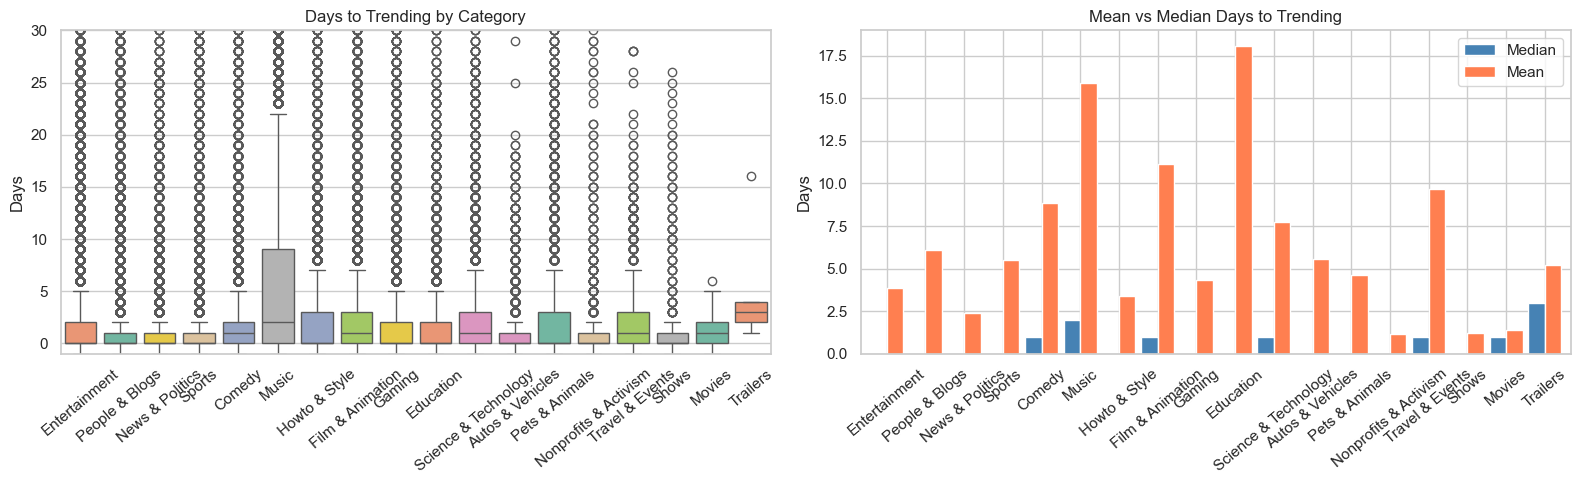

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=df,
    x="category",
    y="days_to_trending",
    order=category_order,
    hue="category",
    dodge=False,
    legend=False,
    ax=axes[0],
    palette="Set2",
)
axes[0].set_ylim(-1, 30)
axes[0].set_title("Days to Trending by Category")
axes[0].set_ylabel("Days")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=40)

trending_speed = df.groupby("category")["days_to_trending"].agg(["median", "mean"])
trending_speed = trending_speed.reindex(category_order)
trending_speed.plot.bar(ax=axes[1], color=["steelblue", "coral"], width=0.85)
axes[1].set_title("Mean vs Median Days to Trending")
axes[1].set_ylabel("Days")
axes[1].set_xlabel("")
axes[1].legend(["Median", "Mean"])
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("exploration_images/category_time_to_trending.png", dpi=150, bbox_inches="tight")
plt.show()


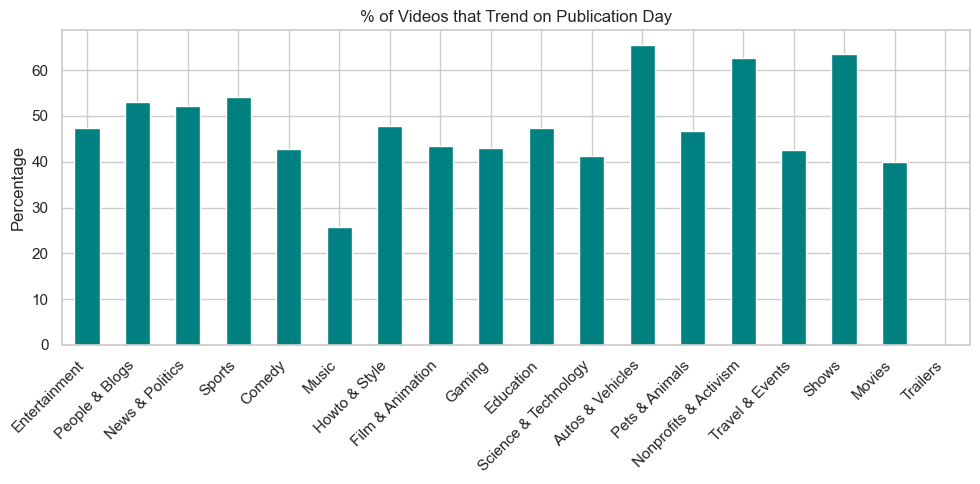

In [13]:
same_day = df[df["days_to_trending"] == 0]
same_day_pct = (
    same_day.groupby("category").size()
    / df.groupby("category").size()
    * 100
).reindex(category_order)

plt.figure(figsize=(10, 5))
same_day_pct.plot.bar(color="teal")
plt.title("% of Videos that Trend on Publication Day")
plt.ylabel("Percentage")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("exploration_images/category_same_day_trending.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Publishing Patterns by Category

When are trending videos in each category published? (UTC hour and day of week.)


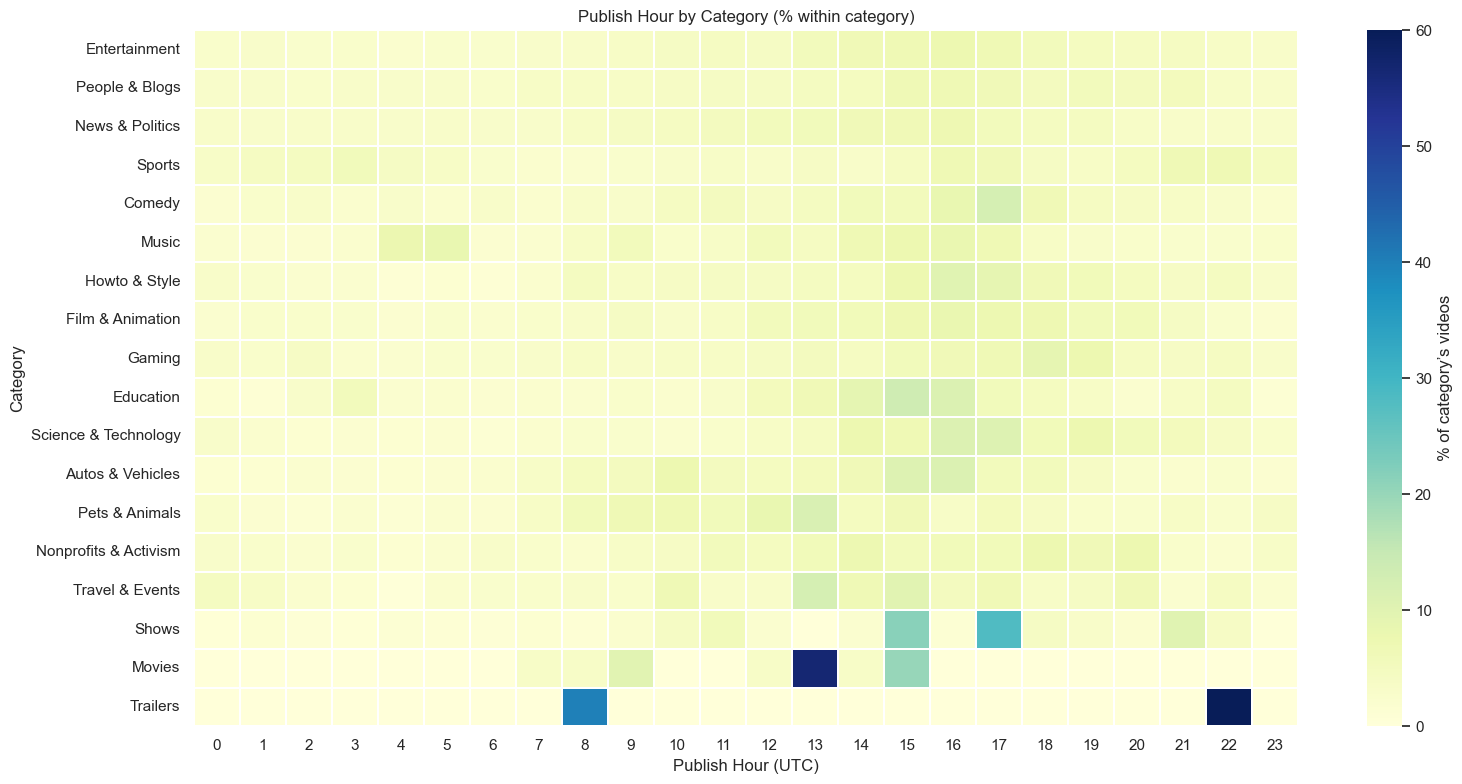

In [14]:
hour_cat = (
    df.groupby(["category", "publish_hour"])
    .size()
    .unstack(fill_value=0)
)
hour_cat_pct = hour_cat.div(hour_cat.sum(axis=1), axis=0) * 100
hour_cat_pct = hour_cat_pct.reindex(category_order)

plt.figure(figsize=(16, 8))
sns.heatmap(
    hour_cat_pct, cmap="YlGnBu", annot=False,
    linewidths=0.3, cbar_kws={"label": "% of category’s videos"}
)
plt.title("Publish Hour by Category (% within category)")
plt.xlabel("Publish Hour (UTC)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("exploration_images/category_publish_hour.png", dpi=150, bbox_inches="tight")
plt.show()


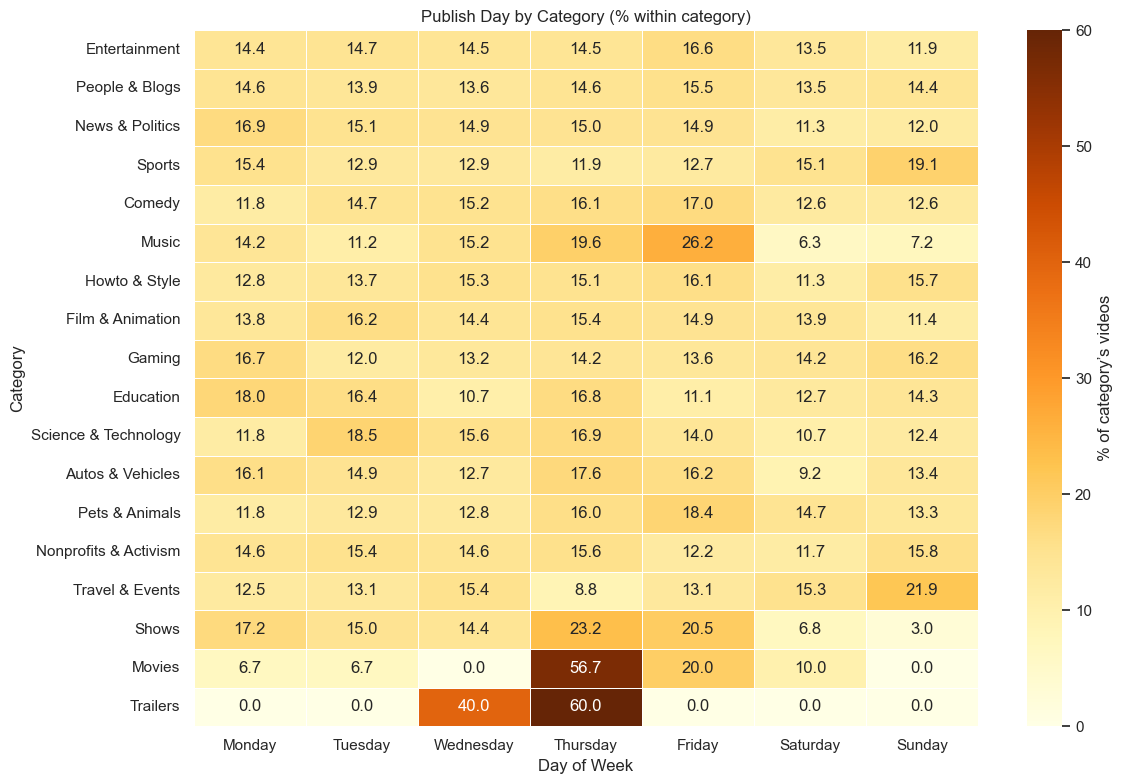

In [15]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_cat = (
    df.groupby(["category", "publish_day"])
    .size()
    .unstack(fill_value=0)
)[day_order]
day_cat_pct = day_cat.div(day_cat.sum(axis=1), axis=0) * 100
day_cat_pct = day_cat_pct.reindex(category_order)

plt.figure(figsize=(12, 8))
sns.heatmap(
    day_cat_pct, cmap="YlOrBr", annot=True, fmt=".1f",
    linewidths=0.5, cbar_kws={"label": "% of category’s videos"}
)
plt.title("Publish Day by Category (% within category)")
plt.xlabel("Day of Week")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("exploration_images/category_publish_day.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Cross-Category Overlap (Channels) and Global Reach

Each video has a single `category_id`, so **video sets do not overlap across categories**. Instead we measure **channel overlap**: Jaccard similarity of `channel_title` sets between categories (channels that trend in both).

We also track how many countries each unique video trends in (`n_countries`), and compare **high reach** (3+ countries) vs **local** (1 country) category mixes—parallel in spirit to the country notebook’s global vs local category bars.


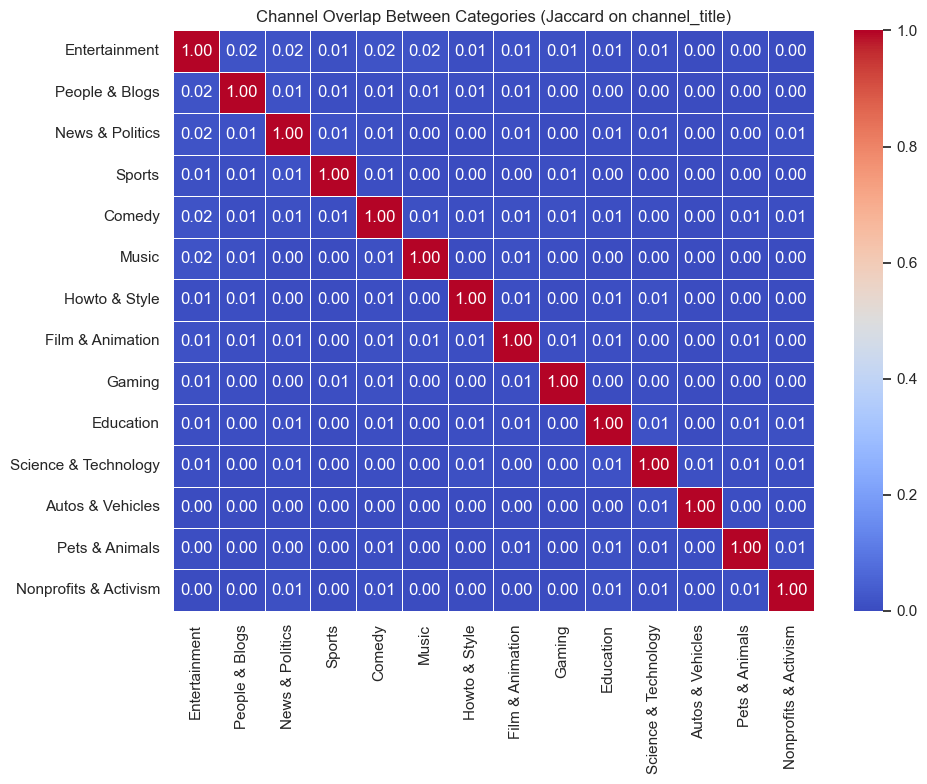

In [16]:
cats = [c for c in category_order if c != "Other"][:14]
channel_sets = {
    c: set(df.loc[df["category"] == c, "channel_title"].dropna().astype(str))
    for c in cats
}

jaccard_ch = pd.DataFrame(index=cats, columns=cats, dtype=float)
for a in cats:
    for b in cats:
        sa, sb = channel_sets[a], channel_sets[b]
        inter = len(sa & sb)
        union = len(sa | sb)
        jaccard_ch.loc[a, b] = inter / union if union > 0 else 0.0

plt.figure(figsize=(10, 8))
sns.heatmap(
    jaccard_ch.astype(float), annot=True, fmt=".2f",
    cmap="coolwarm", vmin=0, linewidths=0.5
)
plt.title("Channel Overlap Between Categories (Jaccard on channel_title)")
plt.tight_layout()
plt.savefig("exploration_images/category_channel_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()


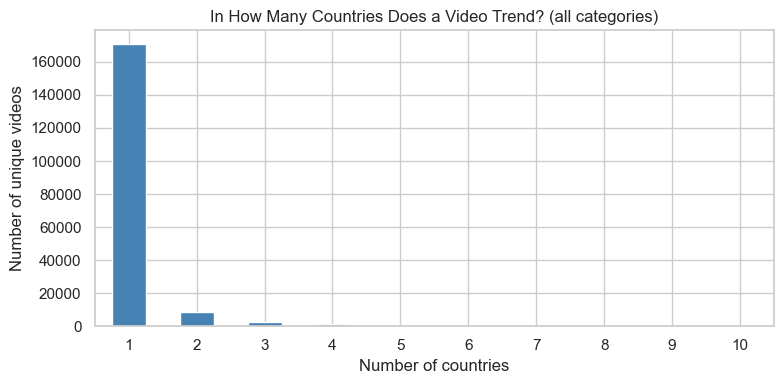

Videos trending in only 1 country: 170518 (92.5%)
Videos trending in 5+ countries:   1014 (0.6%)


In [17]:
n_countries_per_video = df.groupby("video_id")["country"].nunique()

plt.figure(figsize=(8, 4))
n_countries_per_video.value_counts().sort_index().plot.bar(color="steelblue")
plt.title("In How Many Countries Does a Video Trend? (all categories)")
plt.xlabel("Number of countries")
plt.ylabel("Number of unique videos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("exploration_images/category_multi_country_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Videos trending in only 1 country: {(n_countries_per_video == 1).sum()} "
    f"({(n_countries_per_video == 1).mean() * 100:.1f}%)"
)
print(
    f"Videos trending in 5+ countries:   {(n_countries_per_video >= 5).sum()} "
    f"({(n_countries_per_video >= 5).mean() * 100:.1f}%)"
)


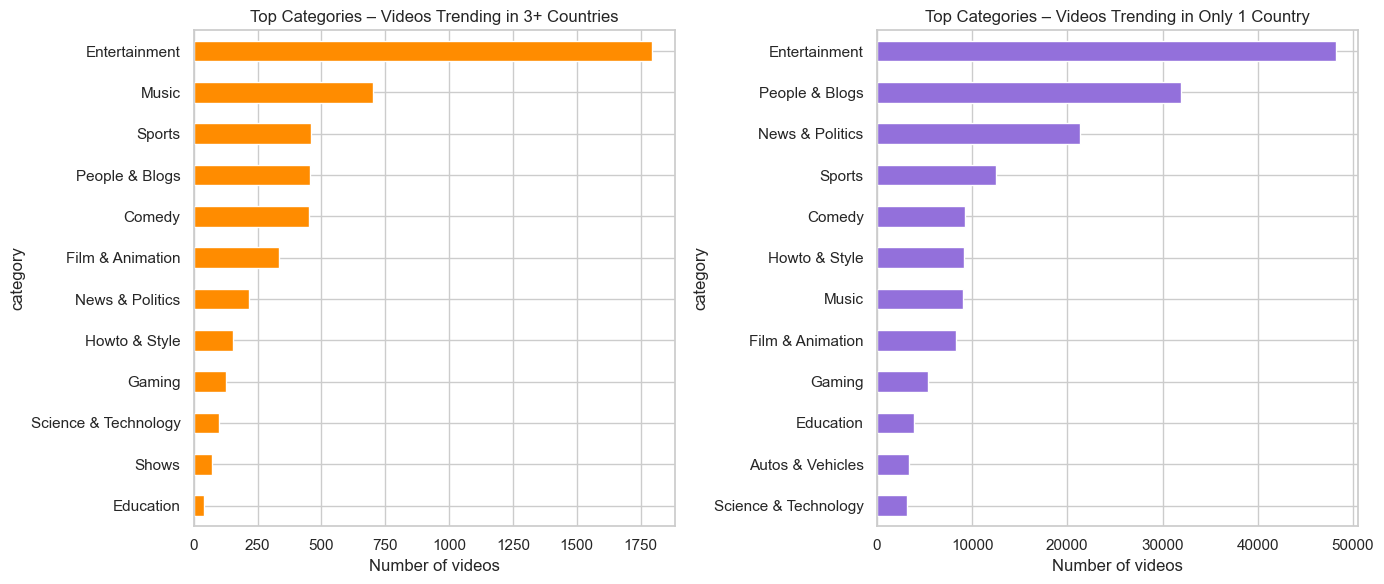

In [18]:
video_meta = df.drop_duplicates("video_id")[["video_id", "category"]].copy()
video_meta["n_countries"] = video_meta["video_id"].map(n_countries_per_video)

global_videos = video_meta[video_meta["n_countries"] >= 3]
local_videos = video_meta[video_meta["n_countries"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

global_videos["category"].value_counts().head(12).plot.barh(ax=axes[0], color="darkorange")
axes[0].set_title("Top Categories – Videos Trending in 3+ Countries")
axes[0].invert_yaxis()
axes[0].set_xlabel("Number of videos")

local_videos["category"].value_counts().head(12).plot.barh(ax=axes[1], color="mediumpurple")
axes[1].set_title("Top Categories – Videos Trending in Only 1 Country")
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of videos")

plt.tight_layout()
plt.savefig("exploration_images/category_global_vs_local.png", dpi=150, bbox_inches="tight")
plt.show()


---

# Temporal Evolution by Category

Monthly windows (`trending_month`) show how category-level metrics move over time. For readability, line charts use the **top 6 categories** by total entries unless noted.


In [19]:
df["trending_month"] = df["trending_date"].dt.to_period("M")

print("Time range:", df["trending_month"].min(), "→", df["trending_month"].max())
print("Number of months:", df["trending_month"].nunique())

top_plot_cats = df["category"].value_counts().head(6).index.tolist()


Time range: 2017-11 → 2018-06
Number of months: 8


## 8. Trending Volume Over Time by Category

Total entries and unique videos per month for the largest categories.


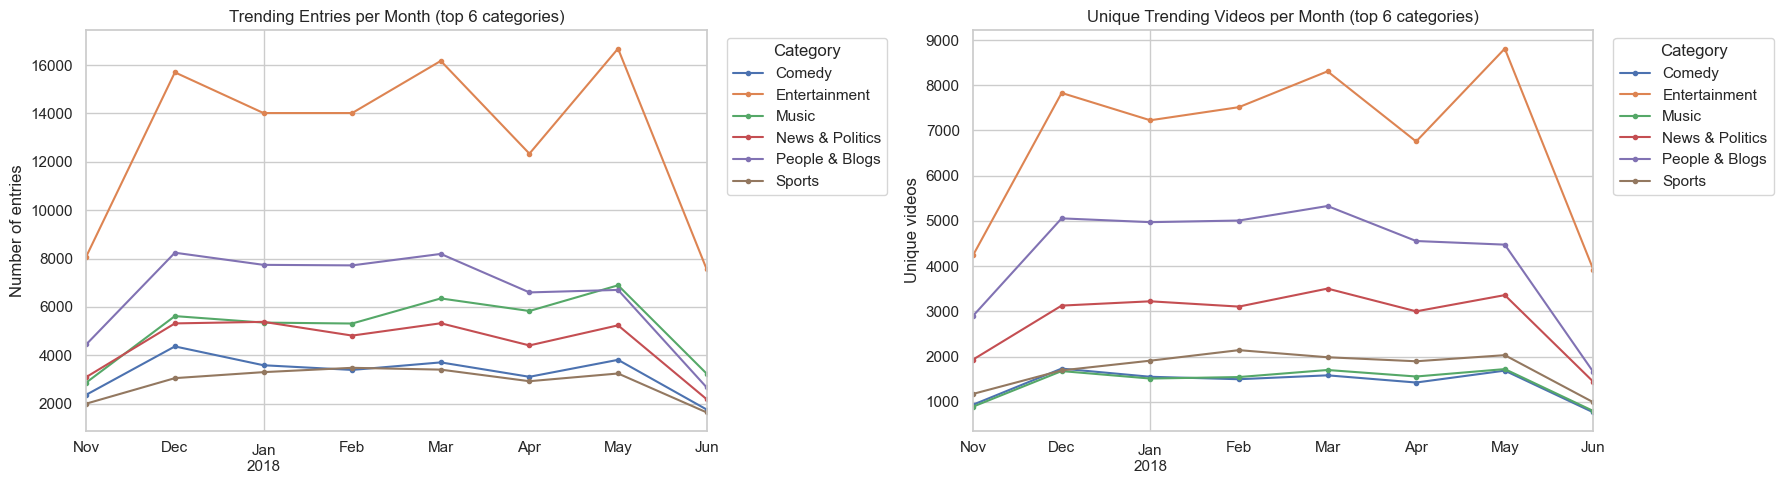

In [20]:
sub = df[df["category"].isin(top_plot_cats)]

monthly_volume = (
    sub.groupby(["trending_month", "category"])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

monthly_volume.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Trending Entries per Month (top 6 categories)")
axes[0].set_ylabel("Number of entries")
axes[0].set_xlabel("")
axes[0].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")

monthly_unique = (
    sub.groupby(["trending_month", "category"])["video_id"]
    .nunique()
    .unstack(fill_value=0)
)
monthly_unique.plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("Unique Trending Videos per Month (top 6 categories)")
axes[1].set_ylabel("Unique videos")
axes[1].set_xlabel("")
axes[1].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("exploration_images/category_volume_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Engagement Evolution Over Time by Category

Median views, likes, and comments month-over-month (top 6 categories).


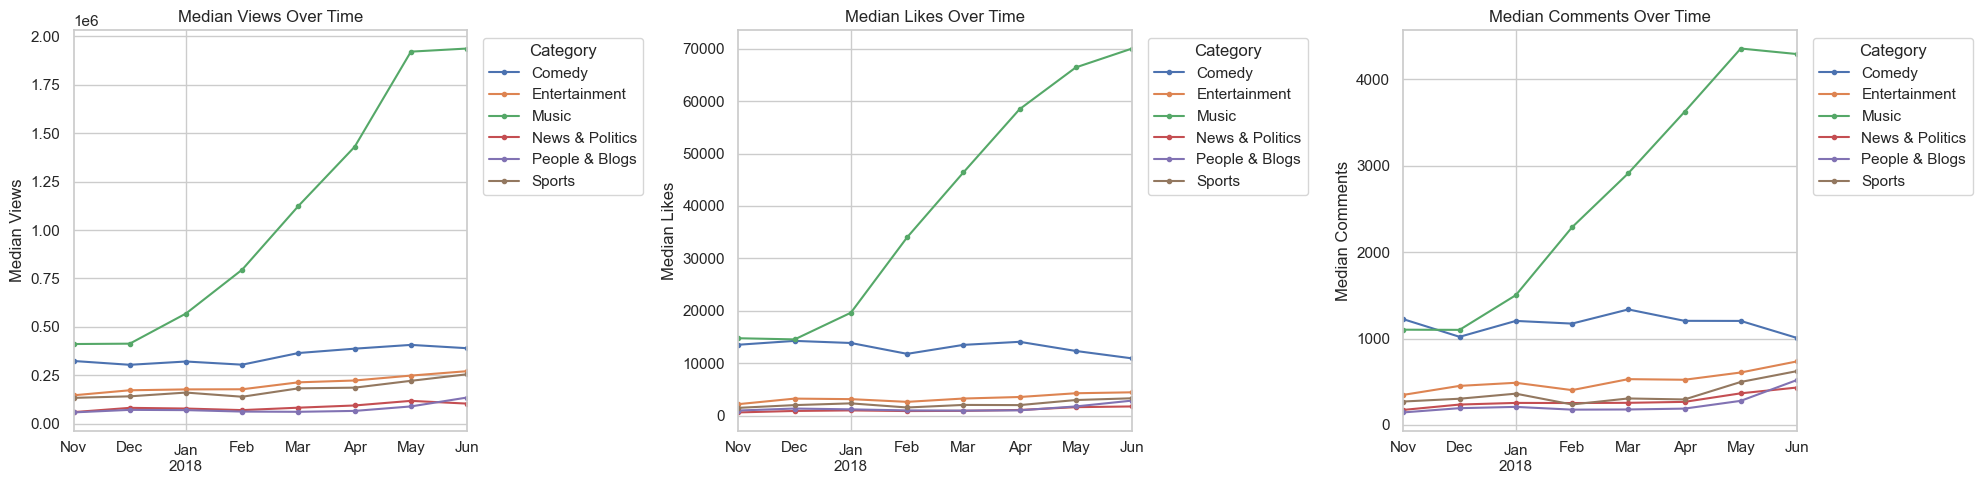

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title in zip(
    axes,
    ["views", "likes", "comment_count"],
    ["Median Views", "Median Likes", "Median Comments"]
):
    pivot = (
        df[df["category"].isin(top_plot_cats)]
        .groupby(["trending_month", "category"])[col]
        .median()
        .unstack(fill_value=0)
    )
    pivot.plot(ax=ax, marker="o", markersize=3)
    ax.set_title(f"{title} Over Time")
    ax.set_ylabel(title)
    ax.set_xlabel("")
    ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("exploration_images/category_engagement_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


Median engagement *rates* over time (likes/views, etc.).


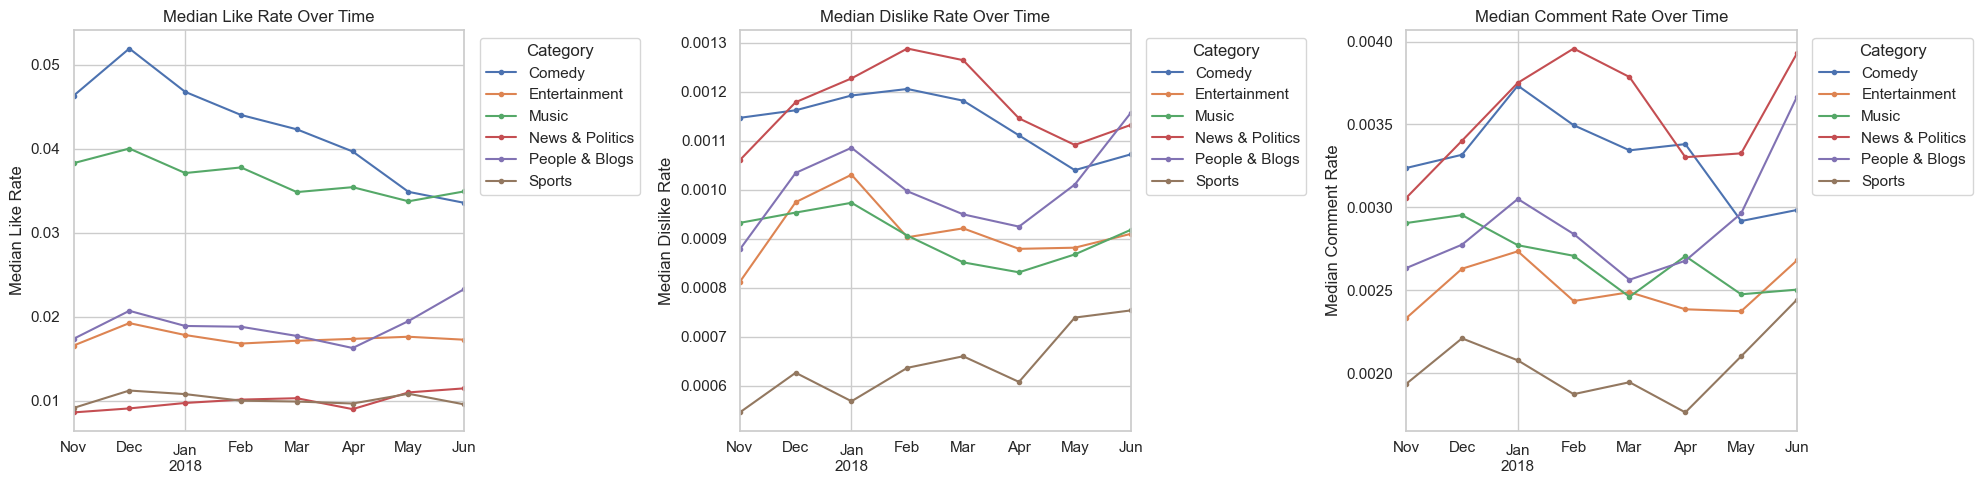

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title in zip(
    axes,
    ["like_rate", "dislike_rate", "comment_rate"],
    ["Median Like Rate", "Median Dislike Rate", "Median Comment Rate"]
):
    pivot = (
        df[df["category"].isin(top_plot_cats)]
        .groupby(["trending_month", "category"])[col]
        .median()
        .unstack(fill_value=0)
    )
    pivot.plot(ax=ax, marker="o", markersize=3)
    ax.set_title(f"{title} Over Time")
    ax.set_ylabel(title)
    ax.set_xlabel("")
    ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("exploration_images/category_engagement_rates_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Country Mix Shifts Over Time (Selected Categories)

Stacked area: share of **countries** within each month’s trending traffic for two contrasting categories (e.g. Music vs News & Politics).


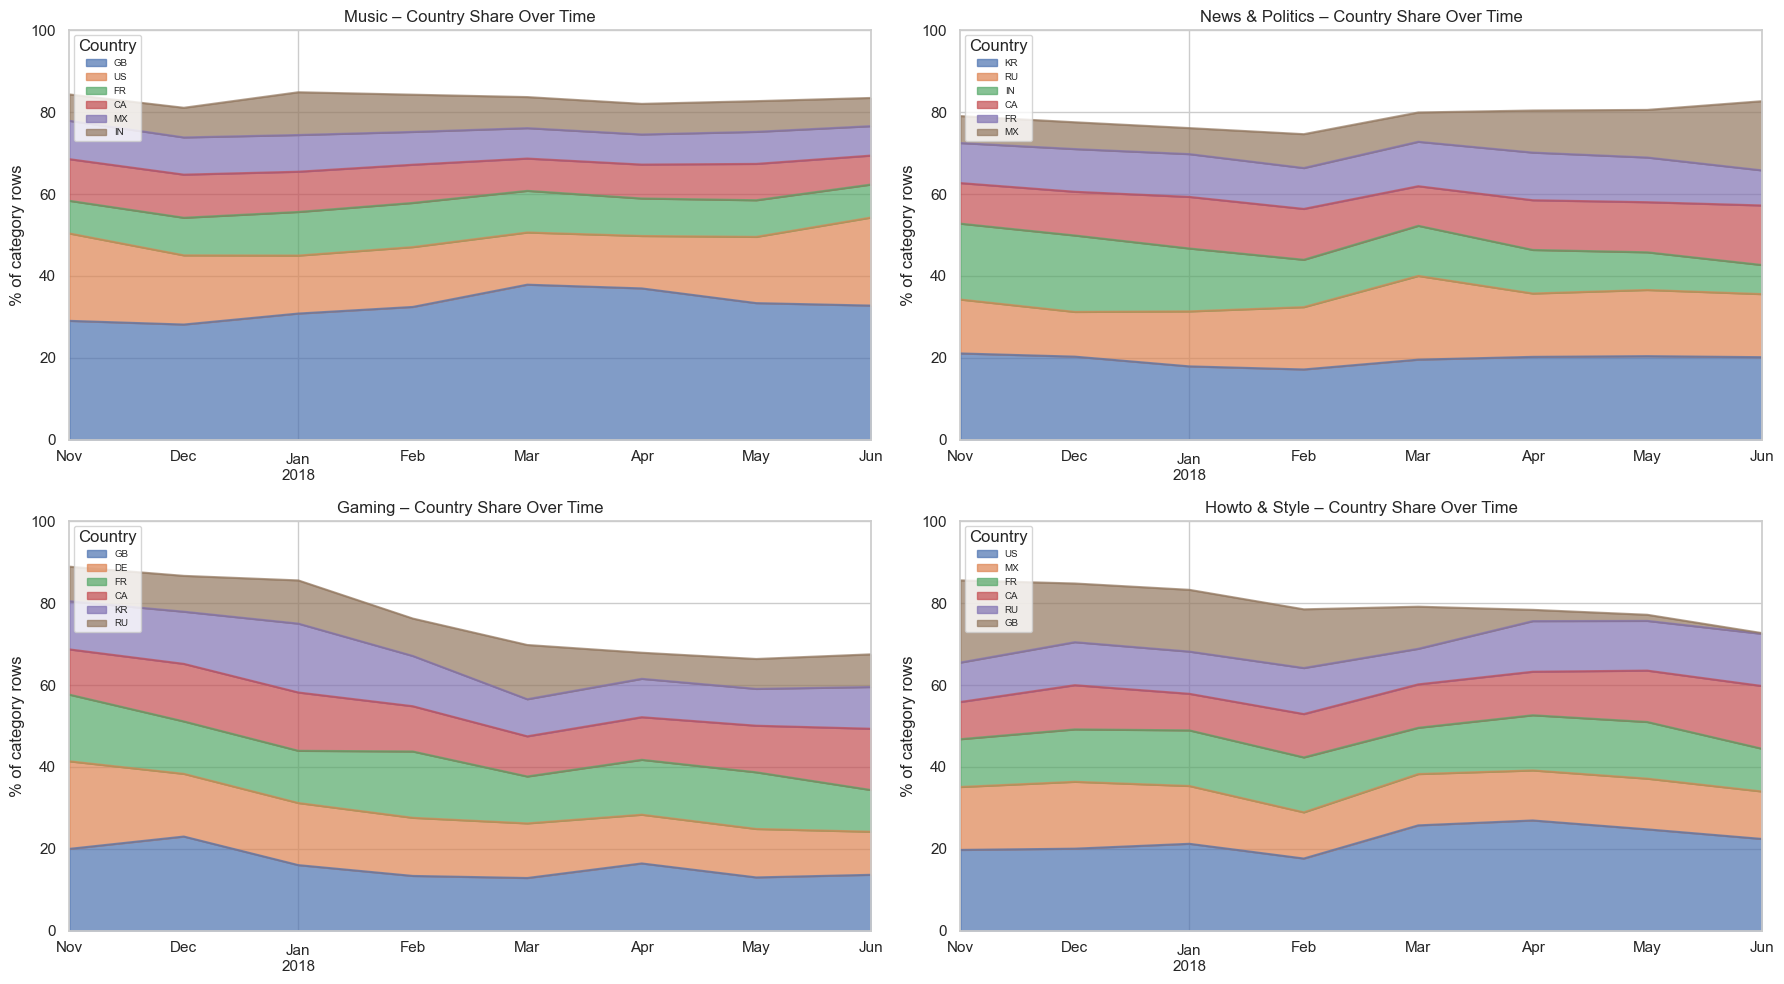

In [23]:
focus_cats = ["Music", "News & Politics", "Gaming", "Howto & Style"]
focus_cats = [c for c in focus_cats if c in df["category"].values]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, cat in zip(axes.flat, focus_cats):
    sub = df[df["category"] == cat]
    ct = (
        sub.groupby(["trending_month", "country"])
        .size()
        .unstack(fill_value=0)
    )
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    cols = ct_pct.sum().nlargest(6).index.tolist()
    ct_pct[cols].plot.area(ax=ax, alpha=0.7, stacked=True)
    ax.set_title(f"{cat} – Country Share Over Time")
    ax.set_ylabel("% of category rows")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.legend(title="Country", fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("exploration_images/category_country_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Time-to-Trending Speed Over Time by Category

Median `days_to_trending` per month (top 6 categories).


<Figure size 1400x500 with 0 Axes>

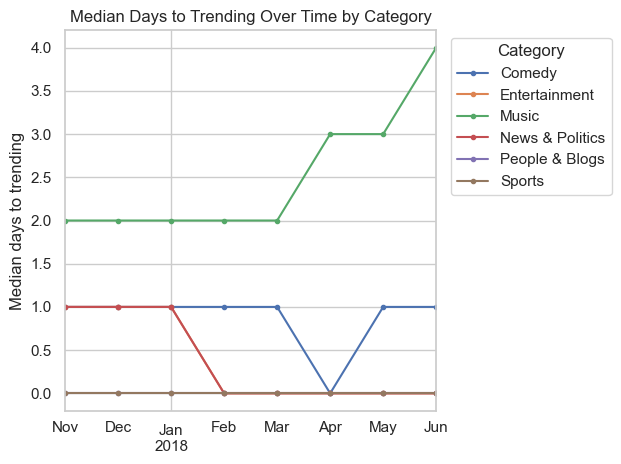

In [24]:
speed_over_time = (
    df[df["category"].isin(top_plot_cats)]
    .groupby(["trending_month", "category"])["days_to_trending"]
    .median()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 5))
speed_over_time.plot(marker="o", markersize=3)
plt.title("Median Days to Trending Over Time by Category")
plt.ylabel("Median days to trending")
plt.xlabel("")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("exploration_images/category_speed_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Multi-Country Reach Over Time (by Category)

For each month and each top category: among **unique videos** in that slice, what percentage trend in **more than one country**? (Analogous to tracking cross-country overlap, but stratified by category.)


<Figure size 1400x500 with 0 Axes>

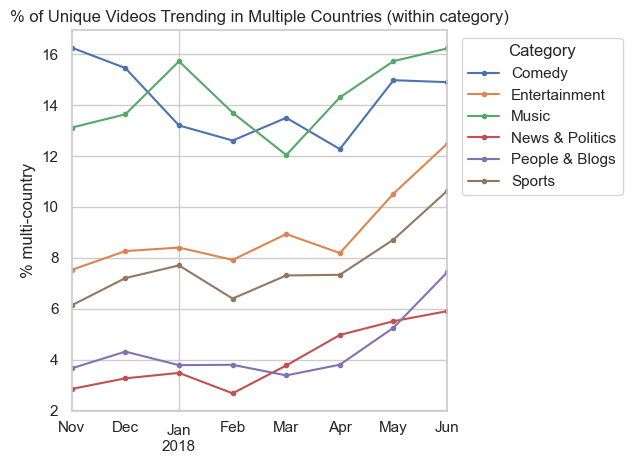

In [25]:
rows = []
for month in sorted(df["trending_month"].dropna().unique()):
    g = df[df["trending_month"] == month]
    for cat in top_plot_cats:
        sg = g[g["category"] == cat]
        if sg.empty:
            continue
        vc = sg.groupby("video_id")["country"].nunique()
        tot = len(vc)
        multi = (vc > 1).sum()
        rows.append({
            "month": month,
            "category": cat,
            "multi_country_pct": multi / tot * 100 if tot else 0,
        })

reach = pd.DataFrame(rows)
reach_pivot = reach.pivot(index="month", columns="category", values="multi_country_pct")

plt.figure(figsize=(14, 5))
reach_pivot.plot(marker="o", markersize=3)
plt.title("% of Unique Videos Trending in Multiple Countries (within category)")
plt.ylabel("% multi-country")
plt.xlabel("")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("exploration_images/category_multi_country_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


<Figure size 1400x500 with 0 Axes>

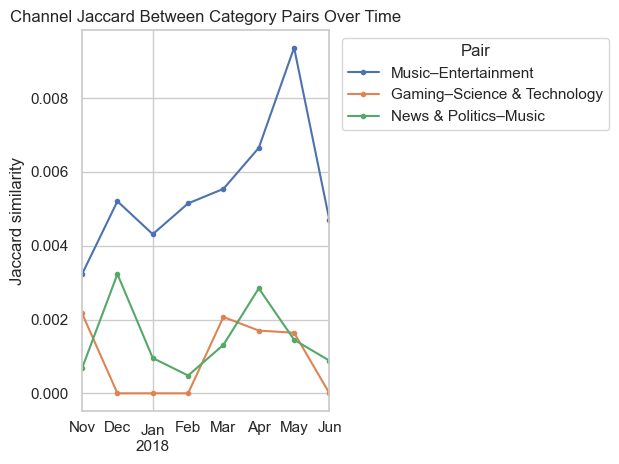

In [26]:
# Jaccard between category video sets within the same month is trivially 0 across categories.
# Optional: channel Jaccard for one category pair over time (Music vs Entertainment)
pairs_cat = [("Music", "Entertainment"), ("Gaming", "Science & Technology"), ("News & Politics", "Music")]
months = sorted(df["trending_month"].dropna().unique())
series = {f"{a}–{b}": [] for a, b in pairs_cat}

for month in months:
    group = df[df["trending_month"] == month]
    for a, b in pairs_cat:
        ca = set(group.loc[group["category"] == a, "channel_title"].dropna().astype(str))
        cb = set(group.loc[group["category"] == b, "channel_title"].dropna().astype(str))
        u = len(ca | cb)
        j = len(ca & cb) / u if u else 0.0
        series[f"{a}–{b}"].append(j)

df_pair = pd.DataFrame(series, index=months)

plt.figure(figsize=(14, 5))
df_pair.plot(marker="o", markersize=3)
plt.title("Channel Jaccard Between Category Pairs Over Time")
plt.ylabel("Jaccard similarity")
plt.xlabel("")
plt.legend(title="Pair", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("exploration_images/category_pair_channel_jaccard_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
